In [1]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data from the data folder
df = pd.read_csv(r"c:\Users\janvi\OneDrive\Documents\Coffee Sale\notebooks\dirty_cafe_sales.csv")

# Explore the first five rows
print("-------- first five rows --------")
print(df.head())

# See the column and data type
print("\n ------- Dataset Information ---------")
df.info()

-------- first five rows --------
  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  

 ------- Dataset Information ---------
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 

In [10]:
# Fill the text (categorical) blanks
df["Item"] = df["Item"].fillna("General Item")
df["Payment Method"] = df["Payment Method"].fillna("Unknown Method")
df["Location"] = df["Location"].fillna("General Location")

df.to_csv("cafe_sales_data1.csv", index=False)

In [11]:
pd.read_csv("Cafe_sales_data1.csv")
# Convert numeric coulmns to float
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

# Convert the Transaction Date in date time format
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df = df.dropna(subset=["Transaction Date"])

# Save the file
df.to_csv("Cafe_sales_data2.csv", index=False)

In [13]:
pd.read_csv("Cafe_sales_data2.csv")

# Calculate missing total
df["Total Spent"] = df["Total Spent"].fillna(df["Quantity"] * df["Price Per Unit"])

# Remove rows that are missing both item and total spent
df = df.dropna(subset=["Item", "Total Spent"], how="all")

# save the file
df.to_csv("Cafe_sales_data3.csv", index=False)

In [14]:
pd.read_csv("Cafe_sales_data3.csv")

# Fill the missing quantity with 1 (Assume at least one was bought)
df["Quantity"] = df["Quantity"].fillna(1)

# Fill the missing Price by working backwards (Total/ Quantity)
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Total Spent"] / df["Quantity"])

# Use the average price of that time to be safe
df["Price Per Unit"] = df.groupby("Item")["Price Per Unit"].transform(lambda x: x.fillna(x.mean()))

# Check the last step 
df["Total Spent"] = df["Total Spent"].fillna(df["Quantity"] * df["Price Per Unit"])

# Save the file
df.to_csv("Cafe_sales_data4.csv", index=False)

In [15]:
pd.read_csv("Cafe_sales_data4.csv")

# Force total spent to match the actual status
mismatches = (df["Total Spent"] != (df["Quantity"] * df["Price Per Unit"])).sum()
print(f"Mathematical Mismatching: {mismatches}")

# Save the file
df.to_csv("Cafe_sales_data5.csv", index=False)

Mathematical Mismatching: 322


Top revenue Generator
Item
Salad           16585.000000
Sandwich        13084.194211
Smoothie        12784.061185
Juice           10032.000000
Cake             9837.024977
General Item     8091.500000
Coffee           6824.008913
Tea              4666.570312
Cookie           3078.000000
Name: Total Spent, dtype: float64
Average spent per location
Location
General Location    8.913049
In-store            9.025102
Takeaway            8.794291
Name: Total Spent, dtype: float64


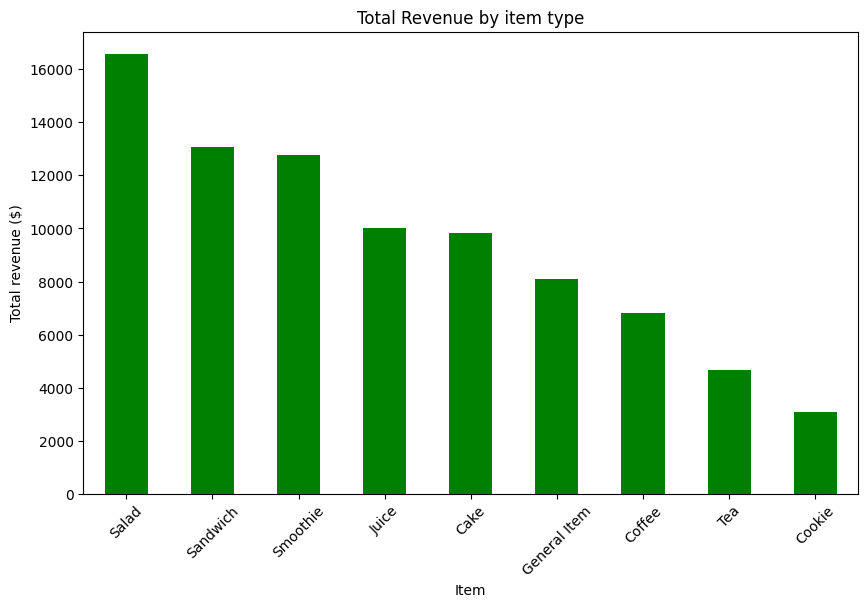

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
pd.read_csv("Cafe_sales_data5.csv")

# Top selling item
item_comparison = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
print("Top revenue Generator")
print(item_comparison)

# Location Efficiency
location_avg = df.groupby("Location")["Total Spent"].mean()
print("Average spent per location")
print(location_avg)

# Create bar chart for items
plt.figure(figsize=(10, 6))
item_comparison.plot(kind="bar", color="green")
plt.title("Total Revenue by item type")
plt.xlabel("Item")
plt.ylabel("Total revenue ($)")
plt.xticks(rotation=45)
plt.savefig("item_comparison.png")
plt.show()

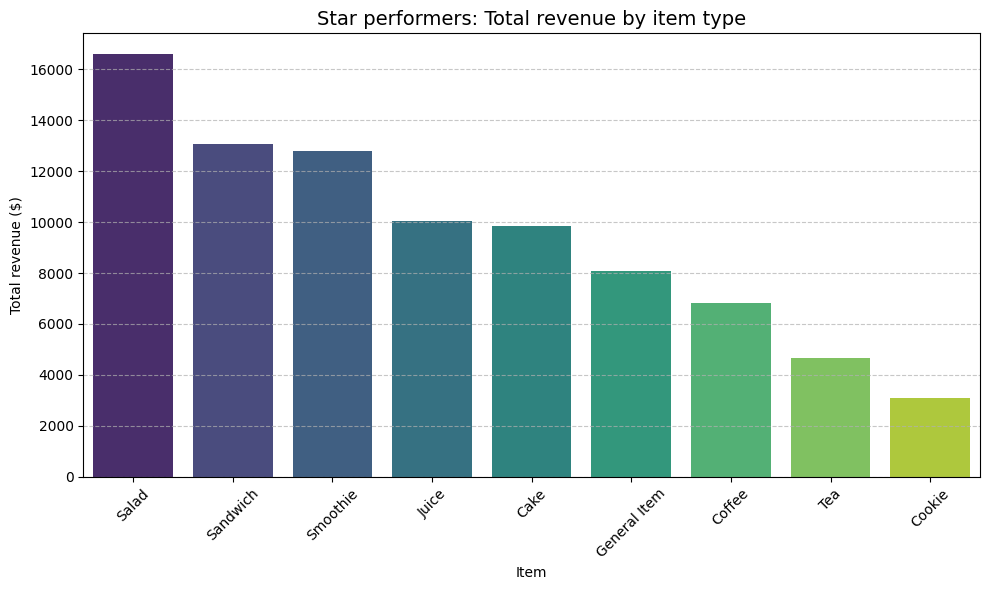

In [29]:
# Star performers (Revenue Analysis)
item_revenue = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=item_revenue, x='Item', y='Total Spent', hue='Item', palette='viridis', legend=False)
plt.title("Star performers: Total revenue by item type", fontsize=14)
plt.ylabel("Total revenue ($)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("star_performers_revenue.png")

plt.show()

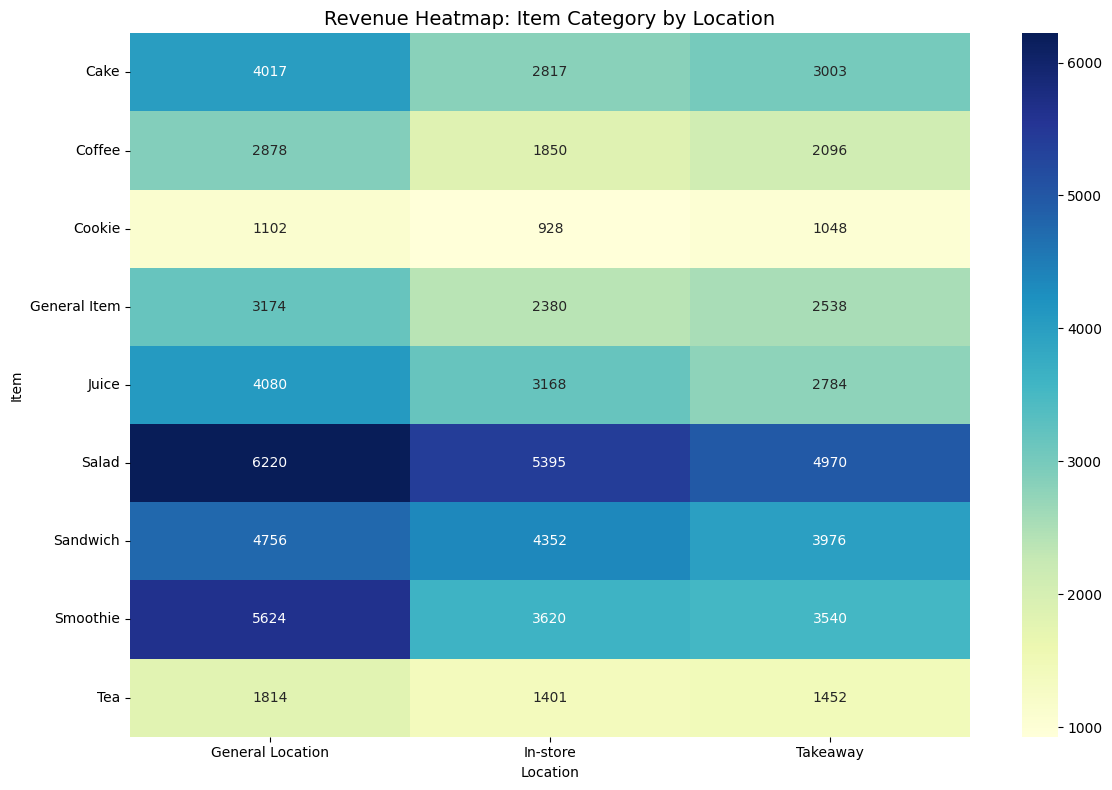

In [30]:
# Cross-section (Heatmap: Item vs Location)
pivot_table = df.pivot_table(index='Item', columns='Location', values='Total Spent', aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Revenue Heatmap: Item Category by Location', fontsize=14)
plt.tight_layout()
plt.savefig('revenue_heatmap_location.png')
plt.show()

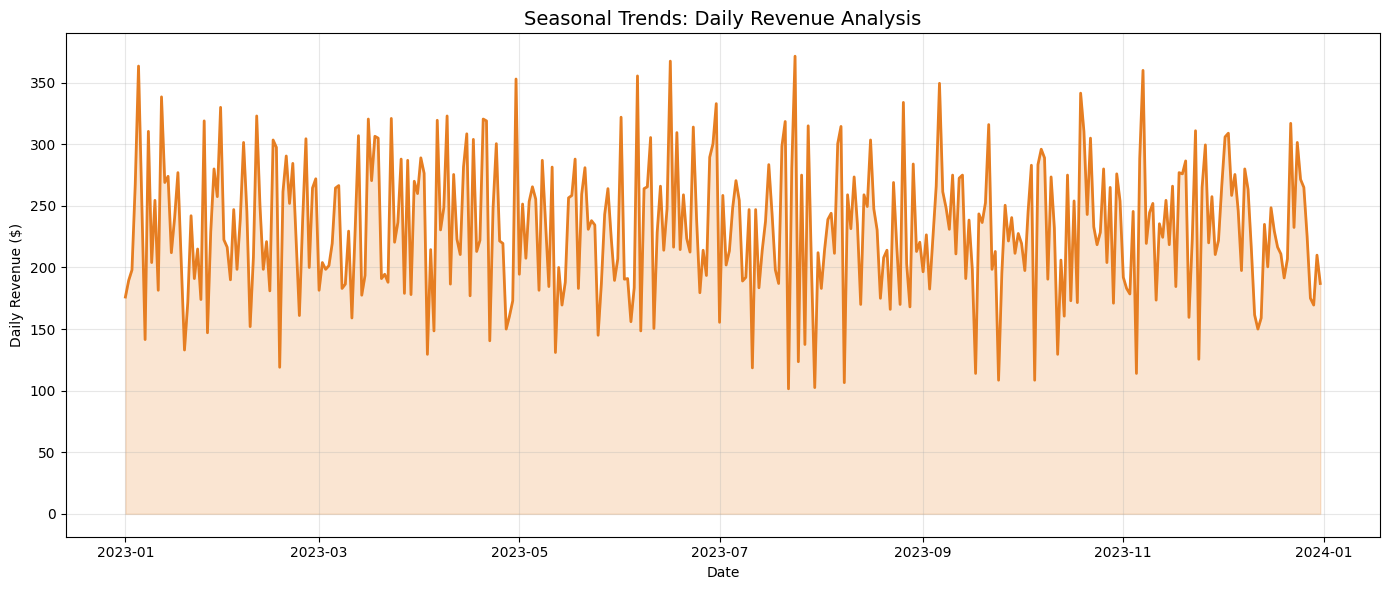

In [32]:
# Seasonal Trends (Daily revenue Trend)
daily_trend = df.groupby('Transaction Date')['Total Spent'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(daily_trend['Transaction Date'], daily_trend['Total Spent'], color='#e67e22', linewidth=2)
plt.fill_between(daily_trend['Transaction Date'], daily_trend['Total Spent'], color='#e67e22', alpha=0.2)
plt.title('Seasonal Trends: Daily Revenue Analysis', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Daily Revenue ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seasonal_daily_trend.png')
plt.show()